In [4]:
%pip install -q langgraph==0.3.31 
%pip install -q langchain-ibm==0.3.10
%pip install -q langchain==0.3.23
%pip install -q langchain_community==0.3.21 


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# DEPRECATED
#%pip install -q pygraphviz==1.7

In [15]:
from langchain_ibm import ChatWatsonx
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import END, MessageGraph, StateGraph

from typing import List, Sequence
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder


In [56]:
import os
from dotenv import load_dotenv

load_dotenv()

watsonx_key = os.environ.get("WATSONX_APIKEY")
project_id = os.environ.get("PROJECT_ID")


from langchain_ibm import ChatWatsonx


In [57]:
llm = ChatWatsonx(
    model_id="ibm/granite-4-h-small",
    url="https://us-south.ml.cloud.ibm.com",
    project_id=project_id
)

In [25]:
generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a professional LinkedIn content assistant tasked with crafting engaging, insightful, and well-structured LinkedIn posts."
            " Generate the best LinkedIn post possible for the user's request."
            " If the user provides feedback or critique, respond with a refined version of your previous attempts, improving clarity, tone, or engagement as needed.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [26]:
generate_chain = generation_prompt | llm

In [27]:
reflection_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a professional LinkedIn content strategist and thought leadership expert. Your task is to critically evaluate the given LinkedIn post and provide a comprehensive critique. Follow these guidelines:

        1. Assess the post’s overall quality, professionalism, and alignment with LinkedIn best practices.
        2. Evaluate the structure, tone, clarity, and readability of the post.
        3. Analyze the post’s potential for engagement (likes, comments, shares) and its effectiveness in building professional credibility.
        4. Consider the post’s relevance to the author’s industry, audience, or current trends.
        5. Examine the use of formatting (e.g., line breaks, bullet points), hashtags, mentions, and media (if any).
        6. Evaluate the effectiveness of any call-to-action or takeaway.

        Provide a detailed critique that includes:
        - A brief explanation of the post’s strengths and weaknesses.
        - Specific areas that could be improved.
        - Actionable suggestions for enhancing clarity, engagement, and professionalism.

        Your critique will be used to improve the post in the next revision step, so ensure your feedback is thoughtful, constructive, and practical.
        """
    ),
    MessagesPlaceholder(variable_name="messages")
])

In [28]:
reflect_chain = reflection_prompt | llm

In [29]:
from typing import List, Annotated, TypedDict
from langchain.schema import HumanMessage, AIMessage, SystemMessage

class AgentState(TypedDict):
    messages: Annotated[List[HumanMessage | AIMessage | SystemMessage], "add_messages"]

In [30]:
from langgraph.graph import MessageGraph
from typing import List, Annotated, TypedDict
from langchain.schema import HumanMessage, AIMessage, SystemMessage

# Initialize a predefined MessageGraph
graph = MessageGraph()

In [31]:
def generation_node(state: Sequence[BaseMessage]) -> List[BaseMessage]:
    generated_post = generate_chain.invoke({"messages": state})
    return [AIMessage(content=generated_post.content)]

In [48]:
def reflection_node(messages: Sequence[BaseMessage]) -> List[BaseMessage]:
    res = reflect_chain.invoke({"messages": messages})  # Passes messages as input to reflect_chain
    return [HumanMessage(content=res.content)]  # Returns the refined message as HumanMessage for feedback

In [ ]:
graph.add_node("generate", generation_node)
graph.add_node("reflect", reflection_node)

In [35]:
graph.add_edge("reflect", "generate")

In [36]:
graph.set_entry_point("generate")

In [37]:
def should_continue(state: List[BaseMessage]):
    print(state)
    print(len(state))
    print("----------------------------------------------------------------------")
    if len(state) > 6:
        return END
    return "reflect"

In [38]:
graph.add_conditional_edges("generate", should_continue)

In [39]:
workflow = graph.compile()

In [50]:
inputs = HumanMessage(content="""Write a linkedin post on getting a software developer job at Microsoft under 160 characters""")

In [51]:
response = workflow.invoke(inputs)

[HumanMessage(content='Write a linkedin post on getting a software developer job at Microsoft under 160 characters', additional_kwargs={}, response_metadata={}, id='bbd0a594-b4d4-4e47-a09d-f99f7e3edbb1'), AIMessage(content='Securing a software developer role at Microsoft requires:\n\n1. Strong technical skills in your domain\n2. Relevant projects demonstrating your expertise\n3. A compelling resume highlighting achievements\n4. Effective networking and interview preparation\n\nPut in the effort, and land your dream job! 💪🏻💻🚀', additional_kwargs={}, response_metadata={}, id='cc18171b-5a8a-431f-8bd2-66e18707097e')]
2
----------------------------------------------------------------------
[HumanMessage(content='Write a linkedin post on getting a software developer job at Microsoft under 160 characters', additional_kwargs={}, response_metadata={}, id='bbd0a594-b4d4-4e47-a09d-f99f7e3edbb1'), AIMessage(content='Securing a software developer role at Microsoft requires:\n\n1. Strong technical s

In [52]:
response[1].content

'Securing a software developer role at Microsoft requires:\n\n1. Strong technical skills in your domain\n2. Relevant projects demonstrating your expertise\n3. A compelling resume highlighting achievements\n4. Effective networking and interview preparation\n\nPut in the effort, and land your dream job! 💪🏻💻🚀'

In [53]:
response[2].content

"Overall Quality, Professionalism, and Alignment with LinkedIn Best Practices:\n\nThe post demonstrates professionalism and adheres to LinkedIn best practices by keeping the content concise, clear, and relevant to the target audience of aspiring software developers. It effectively summarizes the essential steps for securing a developer position at Microsoft without overwhelming the reader with excessive details.\n\nStructure, Tone, Clarity, and Readability:\n\nThe post is well-structured, with each point conveyed in a single-line bullet format, making it easy to read and digest. The tone is engaging and motivational, encouraging readers to pursue their goals with determination. However, the post could benefit from slightly more varied sentence structure to maintain the reader's interest.\n\nPotential for Engagement (Likes, Comments, Shares) and Professional Credibility:\n\nThe post is likely to receive a moderate level of engagement, as it addresses a common goal for many software deve

In [54]:
response[-1].content

'LinkedIn Post: Software Developer at Microsoft in One Sentence (Under 100 Characters)\n\nMicrosoft dev job? 🔍 Nail these:\n🔹 Skills\n🔹 Projects\n🔹 Resume\n🔹 Prep\n\nConsistency wins! 🏆🚀'

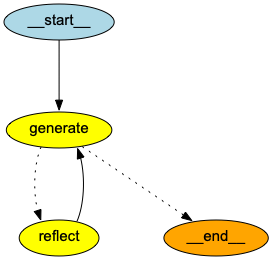

In [55]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_png()))

This table tracks the state transitions in a reflection agent's workflow. Each row represents a step in the process, showing how the state evolves from the initial user input through multiple iterations of generation and reflection. The table captures the iteration number, message type (Human/AI/System), current state, active node (Input/Generate/Reflect), and where the workflow goes next. After 3 iterations, reaching 6 total state changes, the workflow terminates at END.

| Iteration | Type | State | Node | Next Action |
|-----------|------|-------|------|-------------|
| 1 | Human | Initial request | Input | Generate |
| 1 | AI | Generated content | Generate | Reflect |
| 1 | System | Reflection feedback | Reflect | Generate |
| 2 | AI | Revised content | Generate | Reflect |
| 2 | System | Refinement feedback | Reflect | Generate |
| 3 | AI | Final content | Generate | END |


---
As we can see, the final LinkedIn post incorporates feedback by adding a compelling statistic, emphasizing urgency, and suggesting a relevant election topic. It also encourages engagement with a question and includes a visual element, making it more engaging and shareable.